In [1]:
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np

from obspy.core import UTCDateTime, inventory

from cryoquake import data_objects as do
from cryoquake import dayplot_backend as db

from matplotlib import dates as mdates

from sklearn.decomposition import FastICA, PCA

from matplotlib.dates import DateFormatter, DayLocator, HourLocator
import copy
import xarray as xr
import datetime
import pandas as pd

from sklearn.cluster import AgglomerativeClustering, Birch
from matplotlib import rc
import matplotlib.font_manager as fm

from scipy.spatial import distance
from scipy.cluster.hierarchy import dendrogram, cut_tree, to_tree, fcluster

from scipy.cluster import hierarchy

from scipy.stats.mstats import gmean
from matplotlib.colors import LinearSegmentedColormap

import matplotlib.colors as mcolors
from scipy.signal import hilbert

from pathlib import Path

In [2]:
root = Path.cwd()
w_path = root / "waveforms"
s_path = root / "stations"
c_path = root / "catalogues" / 'TI3A_single'
m_path = root / "misfit"
o_path = root / "outputs"
a_path = root / "arrivals"
sc_path = root / "scattering_coefficients"

In [3]:

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.sans-serif'] = 'Computer Modern'
#rc('text', usetex=True)

rc('font', size=9)
rc('xtick',labelsize=8)
rc('ytick',labelsize=8)

In [4]:
inv_files = os.listdir(s_path)

inv = inventory.Inventory()

for file in inv_files:
    temp_path = os.path.join(s_path,file)
    inv += inventory.read_inventory(temp_path,level='response',format='STATIONXML')

inv = inv.select(station='TI?A',channel='CHZ')

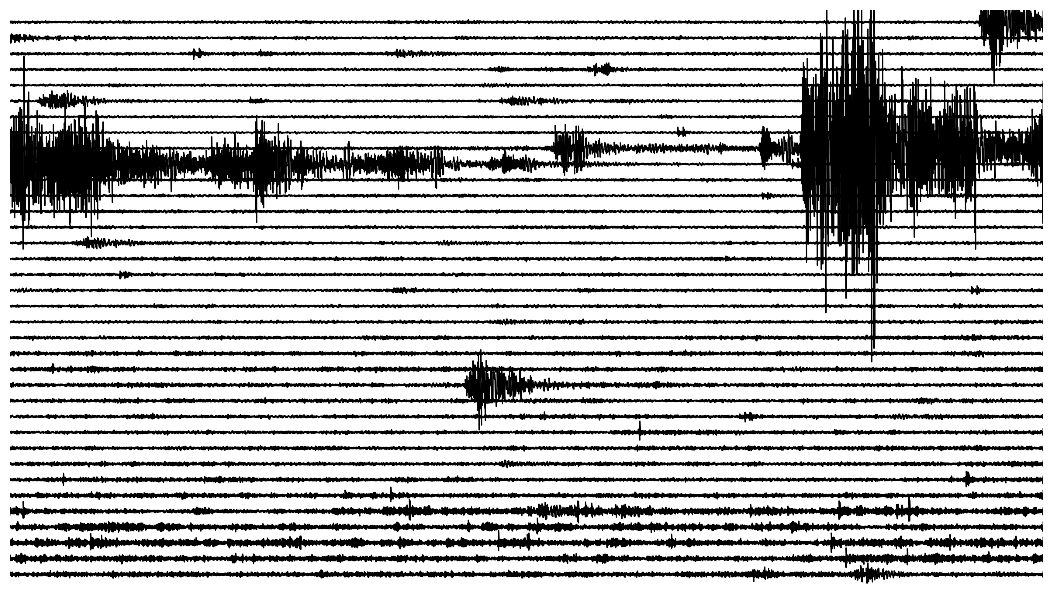

In [103]:
#make a short dayplot of Totten data, then again with events highlighted to show nature of this dataset.
t1 = UTCDateTime(2019,1,3,0)
t2 = UTCDateTime(2019,1,3,12)

chunk = do.SeismicChunk(t1,t2)

chunk.attach_waveforms(inv,w_path,buffer=60*60)
chunk.decimate(5)
#chunk.remove_response(pre_filt=[1,2,45,50],taper=False)
chunk.filter('highpass',freq=1)

dpi = 100
width = 13.33
height = 7.5
mins_per_row = 5
page_length = 6*60*60

fig = plt.figure(figsize=(width,height))
bbs_dayplot = db.StackPlot(fig,mins_per_row=mins_per_row,time_offset=0)

for daychunk in chunk(3*60*60):
    bbs_dayplot.process_chunk(daychunk)
    #bbs_dayplot.add_events(page_chunk,combined_cat)

    bbs_dayplot.normalise_traces()
    fig, ax = bbs_dayplot.make_page('1J.TI3A..CHZ',daychunk)

    plt.axis('off')
    ax.set_title("")

#fig.savefig(os.path.join(o_path,'dayplot.png'),bbox_inches='tight',dpi=400)

In [104]:
sta = 4
lta = 40

thr_on = 3
thr_off = 1.5
thr_coincidence_sum = 1
avg_wave_speed = 1.5
thr_event_join = 5.0

sub_path = os.path.join(c_path)
if not os.path.exists(sub_path):
    os.mkdir(sub_path)

subarray = inv.select(station='TI?A',channel='CH?')

#now make the broadband catalogue
chunk.attach_waveforms(subarray,w_path,buffer=60*60) #hour long buffer for filtering and STA/LTA
chunk.decimate(5)
#daychunk.remove_response(pre_filt=[1,2,20,25],taper=False)   
chunk.filter('bandpass',freqmin=1,freqmax=30)

chunk.context('detect')

print('Detecting events for',chunk.str_name)
chunk.detect_events(sub_path,trigger_type='multistalta',sta=1.0,lta=10.0,delta_sta=10,delta_lta=10,epsilon=1.2,thr_on=3,thr_off=2,thr_coincidence_sum=1,avg_wave_speed=1.5,thr_event_join=5.0) 

Detecting events for 20190103T000000Z__20190103T120000Z
Detecting events for  2019-01-03  -  2019-01-04


/Users/jmagyar/Documents/icequakecode/cryoquake/src/cryoquake/event_detection.py:389: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  traces_df = traces_df.append(trace_df, ignore_index=True)
/Users/jmagyar/Documents/icequakecode/cryoquake/src/cryoquake/event_detection.py:389: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  traces_df = traces_df.append(trace_df, ignore_index=True)
/Users/jmagyar/Documents/icequakecode/cryoquake/src/cryoquake/event_detection.py:389: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  traces_df = traces_df.append(trace_df, ignore_index=True)
/Users/jmagyar/Documents/icequakecode/cryoquake/src/cryoquake/event_detection.py:389: FutureWarning: The frame.append method is deprecated and will be removed from

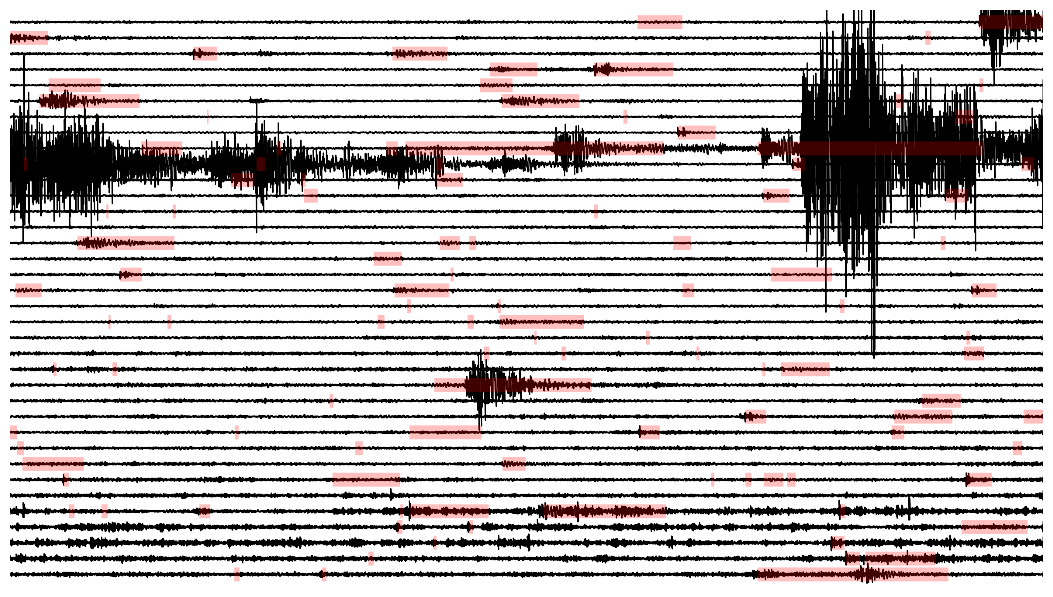

In [105]:
t1 = UTCDateTime(2019,1,3,0)
t2 = UTCDateTime(2019,1,3,12)

chunk = do.SeismicChunk(t1,t2)

bbs_cat = do.EventCatalogue(chunk.starttime,chunk.endtime,c_path)
bbs_cat.events['group'] = 2

chunk.attach_waveforms(inv,w_path,buffer=60*60)
chunk.decimate(5)
#chunk.remove_response(pre_filt=[1,2,45,50],taper=False)
chunk.filter('bandpass',freqmin=1,freqmax=30)

dpi = 200
width = 13.33
height = 7.5
mins_per_row = 5
page_length = 6*60*60

fig = plt.figure(figsize=(width,height))
bbs_dayplot = db.StackPlot(fig,mins_per_row=mins_per_row,time_offset=0)

for daychunk in chunk(3*60*60):
    bbs_dayplot.process_chunk(daychunk)
    bbs_dayplot.add_events(daychunk,bbs_cat)

    bbs_dayplot.normalise_traces()
    fig, ax = bbs_dayplot.make_page('1J.TI3A..CHZ',daychunk)

    plt.axis('off')
    ax.set_title("") 


In [106]:
from scipy.signal import correlate

all_traces = []

chunk.attach_waveforms(inv,w_path,buffer=60*60)
chunk.decimate(5)
#chunk.remove_response(pre_filt=[1,2,45,50],taper=False)
chunk.filter('bandpass',freqmin=1,freqmax=30)

for event in bbs_cat:
    #event.attach_waveforms(inv.select(station='TI?A',channel='CHZ'),w_path,buffer=5)      
    #event.filter('bandpass',freqmin=1,freqmax=30)
    event_stream = chunk.stream.slice(event.starttime-5,event.endtime+5)
    all_traces.append([tr.data for tr in event_stream])


print('Computing cross-correlation matrix...')
N = len(all_traces)
num_sta = len(inv.select(station='TI?A',channel='CHZ'))
cc_mat = np.zeros((N,N))

for i in range(N):
    for j in range(N):
        if i > j:
            pass
        elif i == j:
            cc_mat[i,j] = 1.0
        else:
            cc = np.stack([correlate(all_traces[i][k],all_traces[j][k]) / ((np.sum(all_traces[i][k]**2) * np.sum(all_traces[j][k]**2))**(0.5)) for k in range(num_sta)],axis=-1) #[time shift,stations]
            sort_cc = np.nan_to_num(np.sort(np.nan_to_num(cc,nan=-np.inf),axis=1),neginf=np.nan)    #sort and put nan at start so not included unless less than three stations    
            ave_cc = np.max(np.nanmean(sort_cc[:,-1:],axis=1)) 
            cc_mat[i,j] = ave_cc
            cc_mat[j,i] = ave_cc



cc_mat[cc_mat > 1] = 1.0

dissimilarity = 1-cc_mat
dissimilarity = distance.squareform(dissimilarity) #flattened version - same values as dissimilary so 1 - cc_mat

Computing cross-correlation matrix...


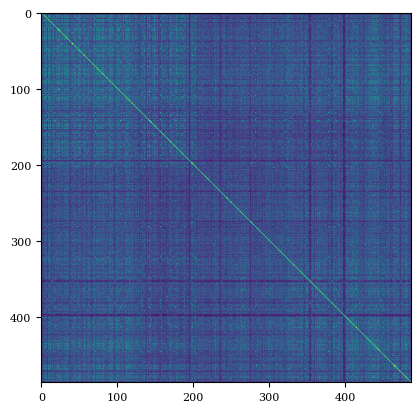

In [107]:
plt.imshow(cc_mat)

In [118]:

from scipy.cluster import hierarchy
from scipy.spatial import distance

print('Hierarchial clustering...')
threshold = 0.3 #make this 0.2 to match the correlation detector

linkage = hierarchy.linkage(dissimilarity, method="centroid",optimal_ordering=True)
clusters = hierarchy.fcluster(linkage, threshold, criterion="distance")

Hierarchial clustering...


In [131]:
print('Template matching...')
#clusters = np.load(os.path.join(c_path,'clusters_N.npz'))['clusters']
#cc_mat = np.load(os.path.join(c_path,'cc_matrix_N.npz'))['cc_mat']


unique = pd.value_counts(clusters)
clust_ind = unique[unique>5] #if 3 or more events in cluster, get template 

templates = {}

for i, clust_N in enumerate(clust_ind):
    clust_id = clust_ind.index[i]

    cc_ind = np.where(clusters==clust_id)[0]
    temp = cc_mat[cc_ind,:]
    clust_cc = temp[:,cc_ind]

    clust_events = bbs_cat.events.index[cc_ind]

    central_ind = np.argmax(np.mean(clust_cc,axis=1))
    central_id = clust_events[central_ind]

    templates[str(clust_id)] = central_id

# #drop these groups as appear to be coda or non stick-slip
# templates.pop('116')
# templates.pop('117')

# full_templates = {}
# full_thresholds = {}
# for temp_name, temp_id in templates.items():
#     template = network_cat.select_event(temp_id)
#     template.attach_waveforms(inv.select(station='TI?A',channel='CHZ'),w_path,buffer=5)
#     template.filter('bandpass',freqmin=1,freqmax=10)   

#     full_templates[temp_name] = template
#     full_thresholds[temp_name] = 0.5

# for daychunk in chunk:
#     daychunk.attach_waveforms(inv.select(station='TI?A',channel='CHZ'),w_path,buffer=60*60)
#     daychunk.filter('bandpass',freqmin=1,freqmax=10)
#     daychunk.context('detect')

#     daychunk.template_catalogue(c_path,full_templates,full_thresholds,method='n_mean',num=3)

Template matching...


In [132]:
templates

{'336': '20190103T070447Z',
 '53': '20190103T103718Z',
 '275': '20190103T101019Z',
 '140': '20190103T023017Z',
 '90': '20190103T001023Z'}

In [111]:
chunk.attach_waveforms(inv,w_path,buffer=60*60)
chunk.decimate(5)
#chunk.remove_response(pre_filt=[1,2,45,50],taper=False)
chunk.filter('bandpass',freqmin=1,freqmax=30)

In [143]:
event_row = bbs_cat.events.loc['20190103T001023Z']
event_start = UTCDateTime(event_row['ref_time'])
event_stream = chunk.stream.slice(event_start-5,event_start+10)

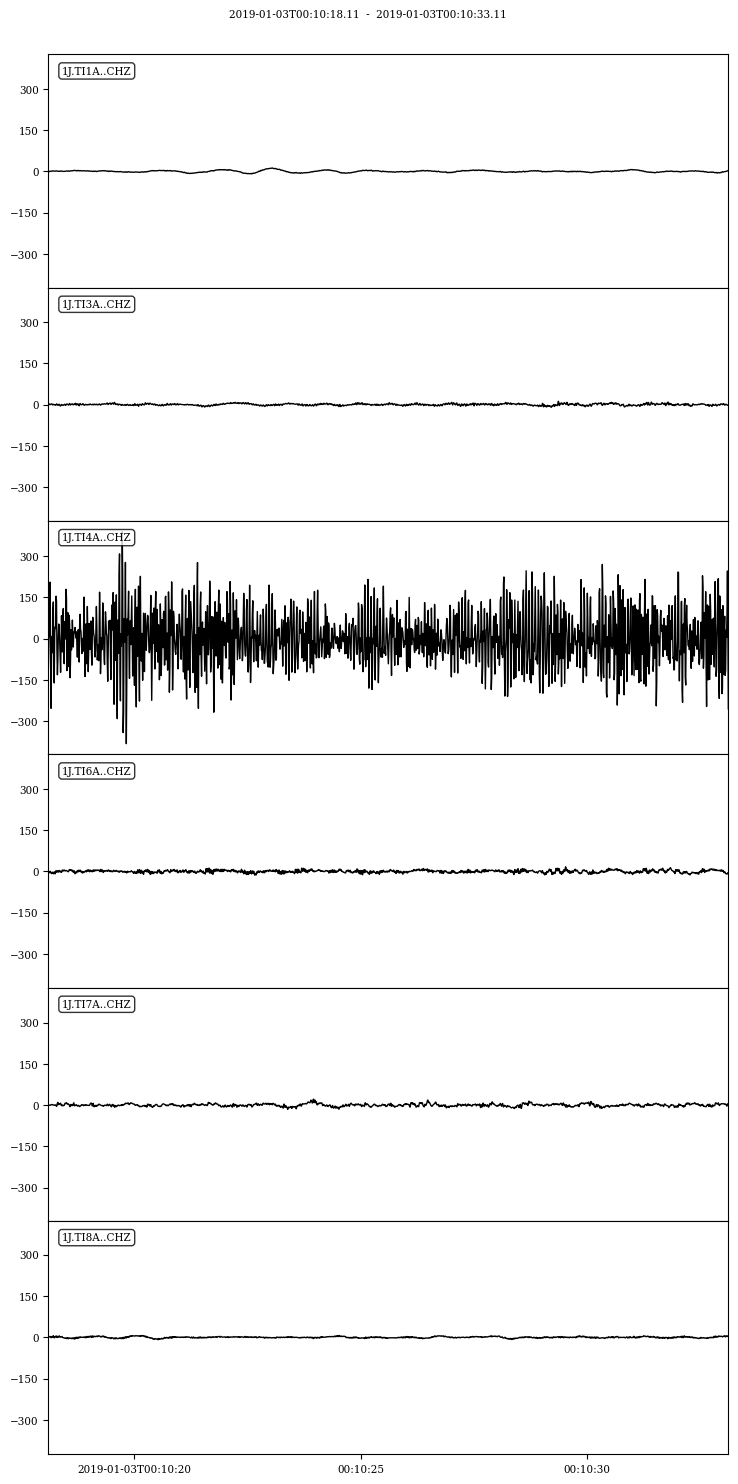

In [144]:
event_stream.plot();

In [145]:
temp_event = bbs_cat.select_event('20190103T001023Z')
temp_event.attach_waveforms(inv.select(station='TI?A',channel='CHZ'),w_path,buffer=10,length=25)
temp_event.filter('bandpass',freqmin=1,freqmax=30)  

AttributeError: 'Series' object has no attribute 'set_index'

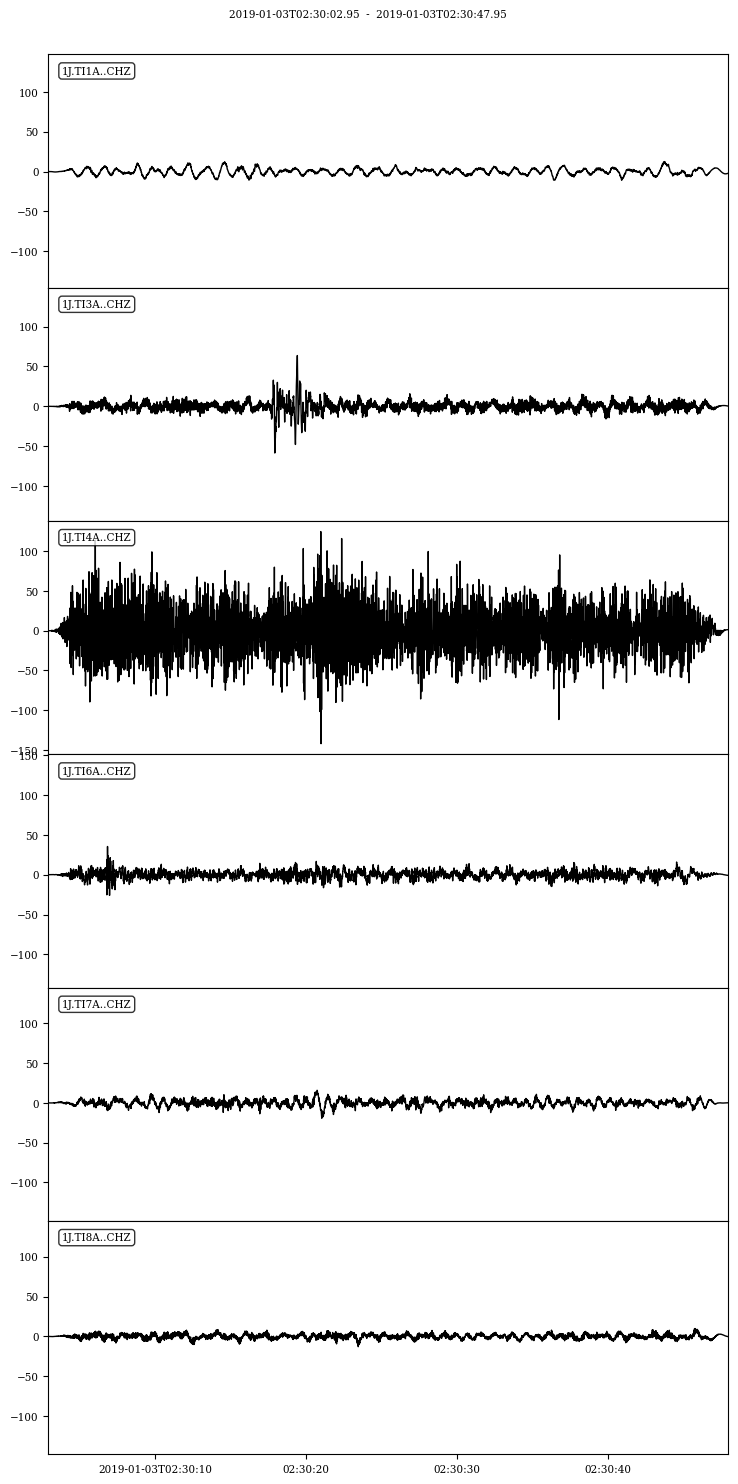

In [97]:
temp_event.stream.plot();